Practical 1: Implement the brute force algorithm for the Vertex Cover problem for n= 10, m= 10,15,.....45. Record the vertex cover along with its size and the running time for each (n,m) pair.  Display the graph and the vertex cover formation visually.

In [ ]:
import random
import time
import networkx as nx
import matplotlib.pyplot as plt

In [ ]:
def vertex_cover(vertex, cover):
    global min_cover
    if vertex > vertices:
        for start, end in edgel:
            if start not in cover and end not in cover:
                return

        if not min_cover or len(cover) < len(min_cover):
            min_cover = cover.copy()
        return

    vertex_cover(vertex + 1, cover + [vertex])
    vertex_cover(vertex + 1, cover)


Vertices : 10
Edges : 10
Minimum Vertex Cover : [2, 4, 6, 7]
Cover Size : 4
Running Time : 0.0011444091796875


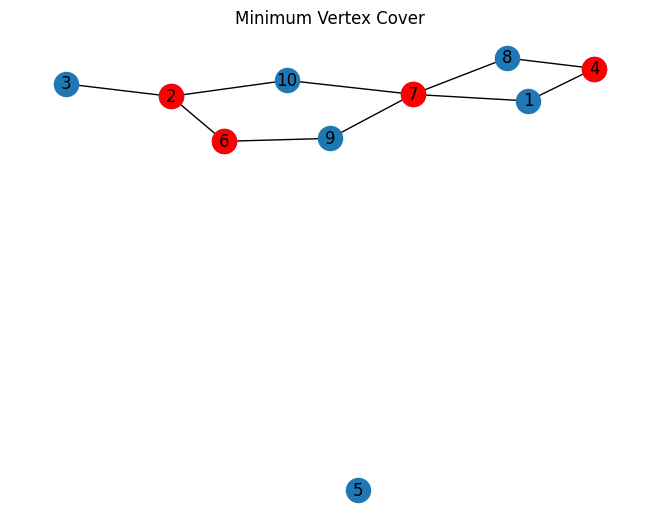


Vertices : 10
Edges : 15
Minimum Vertex Cover : [1, 2, 3, 5, 6, 10]
Cover Size : 6
Running Time : 0.0019211769104003906


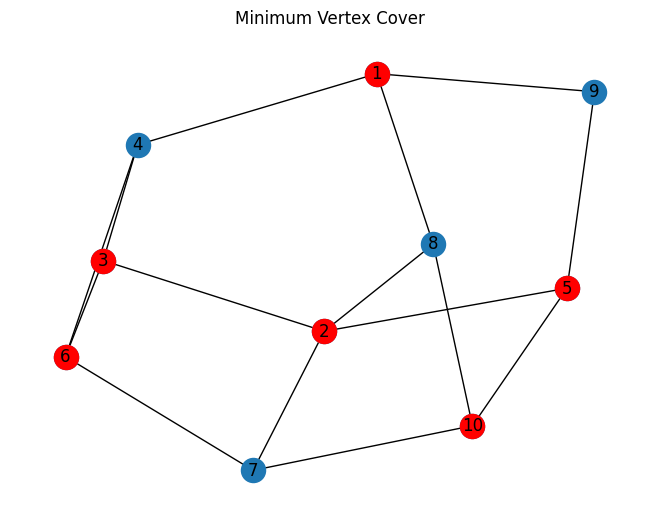


Vertices : 10
Edges : 20
Minimum Vertex Cover : [1, 2, 3, 4, 5, 8, 10]
Cover Size : 7
Running Time : 0.0009131431579589844


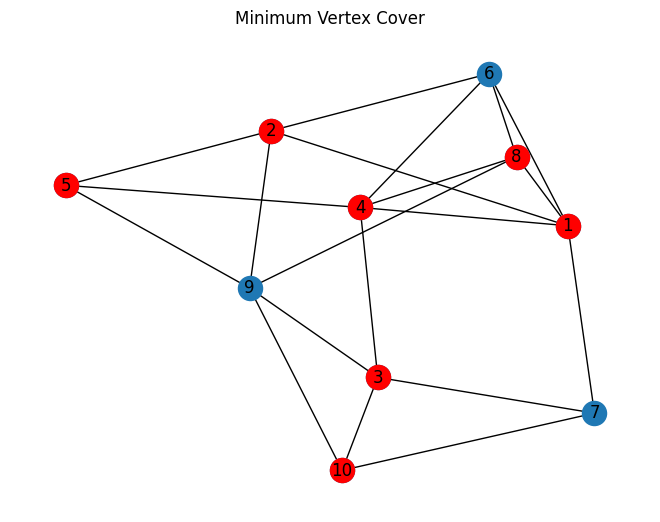


Vertices : 10
Edges : 25
Minimum Vertex Cover : [1, 2, 3, 7, 8, 9]
Cover Size : 6
Running Time : 0.0014529228210449219


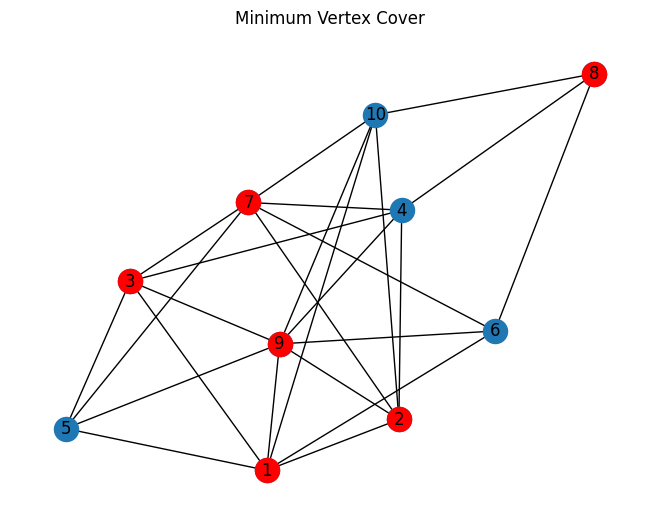


Vertices : 10
Edges : 30
Minimum Vertex Cover : [1, 2, 3, 5, 6, 7, 10]
Cover Size : 7
Running Time : 0.0016245841979980469


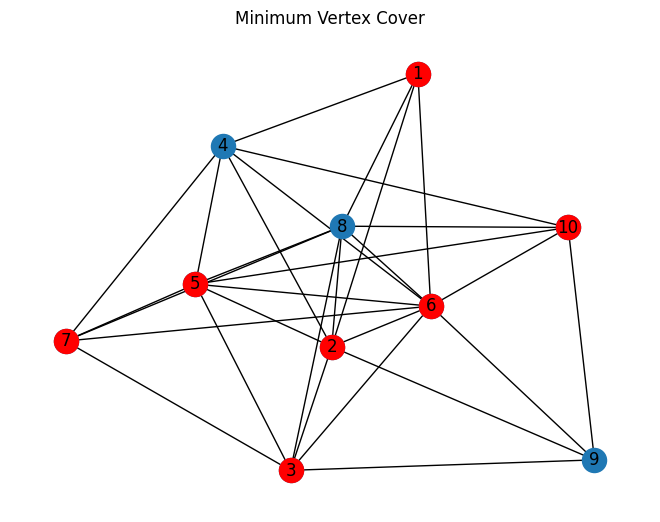


Vertices : 10
Edges : 35
Minimum Vertex Cover : [1, 2, 3, 4, 5, 7, 9, 10]
Cover Size : 8
Running Time : 0.0016834735870361328


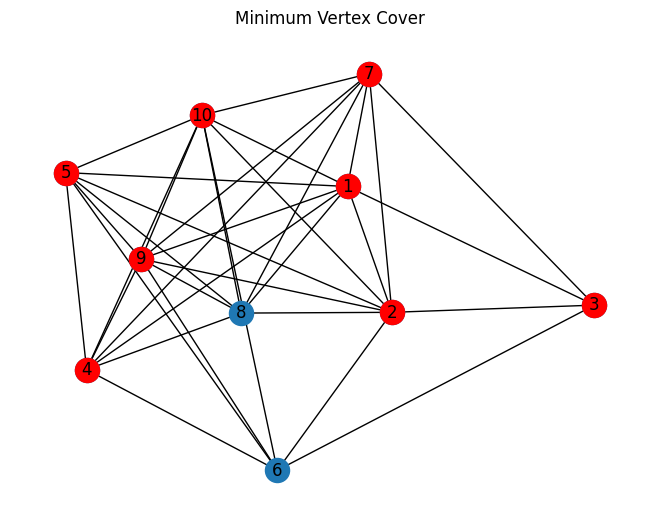


Vertices : 10
Edges : 40
Minimum Vertex Cover : [1, 2, 3, 4, 5, 6, 9, 10]
Cover Size : 8
Running Time : 0.0016193389892578125


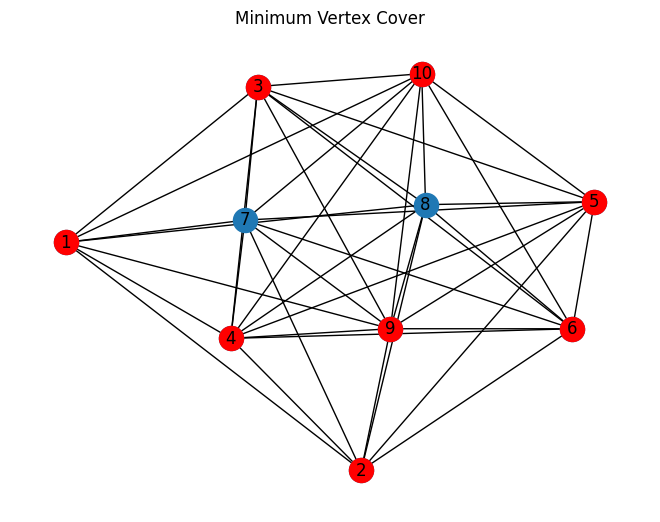


Vertices : 10
Edges : 45
Minimum Vertex Cover : [1, 2, 3, 4, 5, 6, 7, 8, 9]
Cover Size : 9
Running Time : 0.0016644001007080078


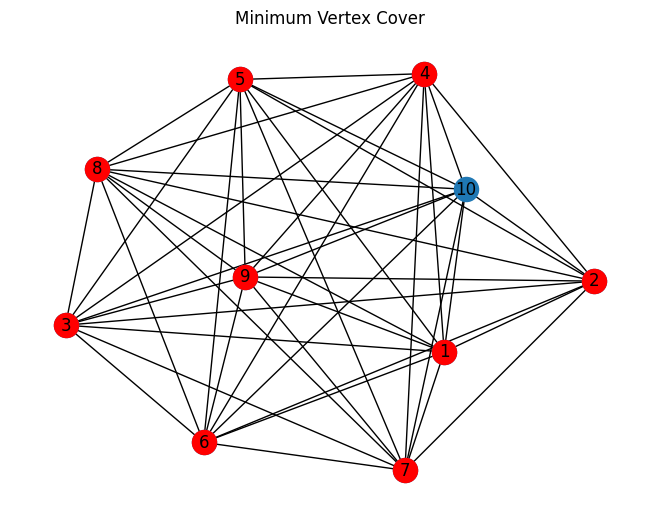

In [ ]:
vertices = 10

for edges in range(10, 46, 5):

    edgel = []

    while len(edgel) < edges:
        start = random.randint(1, vertices)
        end = random.randint(1, vertices)

        if start != end and [start, end] not in edgel and [end, start] not in edgel:
            edgel.append([start, end])
    file_name="file_vc"+str(edges) +".txt"

    with open(file_name, "w") as file:
        for start, end in edgel:
            file.write(str(start) + "," + str(end) + "\n")

    graph = nx.Graph()

    with open(file_name, "r") as file:
        for line in file:
            start, end = line.strip().split(",")
            graph.add_edge(int(start), int(end))

    graph.add_nodes_from(range(1, vertices + 1))

    min_cover = []

    start_time = time.time()

    vertex_cover(1, min_cover)

    end_time = time.time()

    print("\nVertices :", vertices)
    print("Edges :", edges)
    print("Minimum Vertex Cover :", min_cover)
    print("Cover Size :", len(min_cover))
    print("Running Time :", end_time - start_time)

    o_file = "vertex_cover_output_"+str(edges) +".txt"
    with open(o_file, "w") as file:
      file.write("\nVertices : " + str(vertices) + "\n")
      file.write("Edges : " + str(edges) + "\n")
      file.write("Minimum Vertex Cover : " + str(min_cover) + "\n")
      file.write("Cover Size : " + str(len(min_cover)) + "\n")
      file.write("Running Time : " + str(end_time - start_time) + "\n")


    pos = nx.spring_layout(graph)

    nx.draw(graph, pos, with_labels=True)

    nx.draw_networkx_nodes(graph, pos,nodelist=min_cover,node_color="red")

    plt.title("Minimum Vertex Cover")
    plt.savefig("graph_" + str(edges) + "_edges.png")
    plt.show()
    plt.close()